# Part 2 Analysis

## 1. Define Term Structure Models Module

The supporting code lives in `part2/analysis.py`.  It exposes a single class,
`Part2Solver`, which wraps the NSS and CIR routines used elsewhere in the project.
The file is imported below; you can open it if you wish to inspect the implementation.

In [43]:
import sys, os
# make sure the notebook / script is run from the repo root
sys.path.insert(0, os.path.abspath("src"))

import fi_pricing
import inspect
import part2.analysis as analysis

## 2. Import Dependencies and Load Data

We grab a configuration object and create the solver.  The NSS coefficients are read
from the Excel file in the repository; there is nothing else to load manually.

In [44]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from part2.analysis import Part2Config, Part2Solver

# adjust repo root as needed
REPO_ROOT = Path(".").resolve()
cfg = Part2Config(
    repo_root=REPO_ROOT,
    excel_path=REPO_ROOT / "data for projectTP1 data 60201 W2026.xlsx",
)
solver = Part2Solver(cfg)


In [45]:

# Question 1: build weekly series and show descriptive statistics
weekly_df = solver.weekly.df if solver.weekly is not None else solver.compute_weekly()
stats_df = solver.stats if solver.stats is not None else solver.compute_stats()
print("Descriptive statistics for each maturity:")
display(stats_df)


Descriptive statistics for each maturity:


,Maturity,Mean,Std,Q1,Median,Q3
0,3M,2.842952,2.160096,0.218009,3.639531,4.931027
1,6M,2.815641,2.090582,0.219845,3.689847,4.789102
2,1Y,2.752599,1.976020,0.245916,3.579286,4.539148
3,3Y,2.641048,1.671097,0.733470,3.474668,4.093740
4,5Y,2.678781,1.513737,1.115698,3.436988,3.993853
5,10Y,2.925587,1.384548,1.617464,3.435139,4.224936
6,30Y,3.432659,1.224451,2.237609,3.757467,4.568139


## 3. Estimate Instantaneous Risk-Free Rate

Use the solver to run the EKF/MLE and retain the filtered short-rate path.

In [47]:
fit = solver.estimate_cir()
print(f"CIR parameters:\n  kappa={fit.kappa:.4f}, theta={fit.theta:.4f}, sigma={fit.sigma:.4f}, r0={fit.r0:.4f}")

# store filtered short-rate path for later
cir_path = solver.r_path

NameError: name 'log_params' is not defined

In [46]:
# reload module to pick up code edits and rerun CIR estimation
import importlib
import part2.analysis as analysis
importlib.reload(analysis)
from part2.analysis import Part2Solver, Part2Config, nss_instantaneous_short_rate_percent

# recreate solver with existing cfg and recompute weekly yields
solver = Part2Solver(cfg)
_ = solver.compute_weekly()

# run estimation again
fit = solver.estimate_cir()
print(f"kappa={fit.kappa:.4f}, theta={fit.theta:.4f}, sigma={fit.sigma:.4f}, r0={fit.r0:.4f}, lambda={fit.lambda_risk:.4f}")

print("parameter table via helper")
print(solver.get_parameter_table())


NameError: name 'log_params' is not defined

In [39]:
# inspect r_path mean
print("mean of filtered short rate (%)", solver.r_path.mean())
print("first few r_path", solver.r_path[:5])

mean of filtered short rate (%) 1.2561608054815923
first few r_path [1.e-08 1.e-08 1.e-08 1.e-08 1.e-08]


## 4. Fit Nelson-Siegel-Svensson Short Rate

The NSS short rate is simply \(\beta_0+\beta_1\) from the coefficient file.  The
solver already loaded the NSS data earlier, so we can construct the series directly.

In [40]:
# compute NSS short rate for each date
from part2.nss_weekly import nss_instantaneous_short_rate_percent
nss_sr = nss_instantaneous_short_rate_percent(solver.nss.df)

# dates align with solver.weekly.dates
dates = solver.weekly.dates
print("first few NSS short rates:", nss_sr[:5])

ModuleNotFoundError: No module named 'part2.nss_weekly'

## 5. Plot and Compare Rate Path

The two short‑rate series are plotted on the same axes for visual comparison.

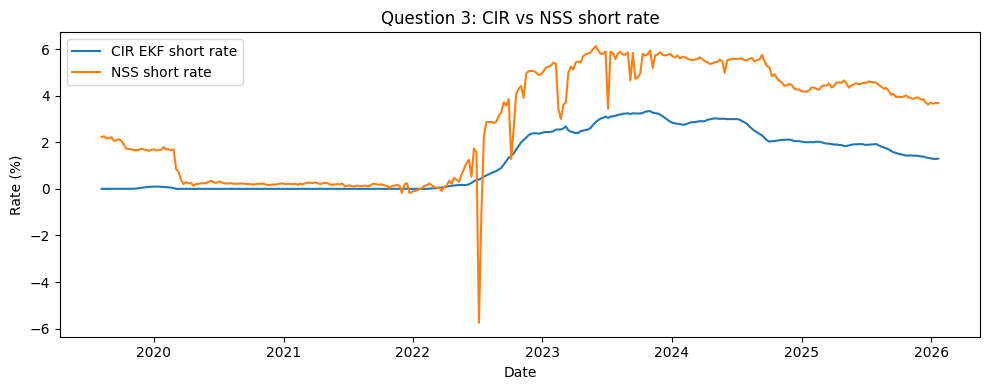

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(dates, cir_path, label="CIR EKF short rate")

# NSS short rate computed via helper in analysis module
from part2.analysis import nss_instantaneous_short_rate_percent
nss_sr = nss_instantaneous_short_rate_percent(solver.nss.df)

plt.plot(dates, nss_sr, label="NSS short rate")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.title("Question 3: CIR vs NSS short rate")
plt.tight_layout()
plt.show()